In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import xgboost as xgb
from xgboost import XGBClassifier


In [67]:
files = !ls data

In [68]:
files

['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'Monday-WorkingHours.pcap_ISCX.csv',
 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 'Tuesday-WorkingHours.pcap_ISCX.csv',
 'Wednesday-workingHours.pcap_ISCX.csv']

In [69]:
dataframes = []

for file in files:
    file_path = "data/" + file
    
    df_temp = pd.read_csv(file_path)
    df_temp.columns = df_temp.columns.str.strip()
    
    # konwersja float64 -> float32 oraz int64 -> int32
    for col in df_temp.select_dtypes(include=['float64']).columns:
        df_temp[col] = df_temp[col].astype('float32')
        
    for col in df_temp.select_dtypes(include=['int64']).columns:
        df_temp[col] = df_temp[col].astype('int32')
        
    dataframes.append(df_temp)

print("\nŁączenie zbiorów...")
df = pd.concat(dataframes, ignore_index=True)

print(f"Gotowe! Rozmiar: {df.shape}")
df.info(memory_usage='deep')


Łączenie zbiorów...
Gotowe! Rozmiar: (2830743, 79)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int32  
 1   Flow Duration                int32  
 2   Total Fwd Packets            int32  
 3   Total Backward Packets       int32  
 4   Total Length of Fwd Packets  int32  
 5   Total Length of Bwd Packets  int32  
 6   Fwd Packet Length Max        int32  
 7   Fwd Packet Length Min        int32  
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        int32  
 11  Bwd Packet Length Min        int32  
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float32
 15  Flow Packets/s               float32
 16  Flow IAT Mean                float32
 17  Flow IAT Std                 flo

In [70]:
print(f"rozmiar: {df.shape}")
df.head()

target_col = 'Label'

rozmiar: (2830743, 79)


<Axes: xlabel='Label'>

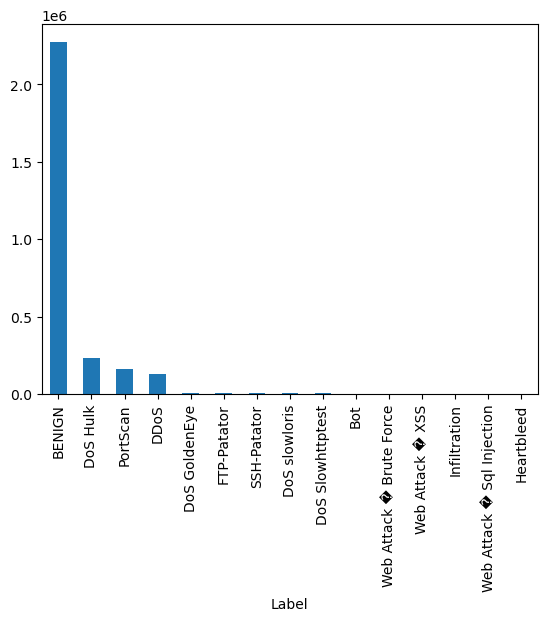

In [71]:
df[target_col].value_counts().plot(kind='bar')

In [72]:
df[target_col] = df[target_col].apply(lambda x: 1 if x.strip() == 'DDoS' else 0)

In [73]:
# Kodowanie kolumn tekstowych (categorical features)
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    df[col] = df[col].astype('category')
    df[col].value_counts().plot(kind='bar')

print("Mapowanie zakończone")

Mapowanie zakończone


In [74]:
df = df.replace([np.inf, -np.inf], np.nan)

In [75]:
X = df.drop([target_col], axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Rozmiar treningowy: {X_train.shape}")
print(f"Rozmiar testowy: {X_test.shape}")

Rozmiar treningowy: (2264594, 78)
Rozmiar testowy: (566149, 78)


In [76]:
# Ustalenie hiperparametrów
params = {
    'n_estimators': 50,
    'max_depth': 5,
    'learning_rate': 0.1,
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'random_state': 42
}

model = XGBClassifier(**params)
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [79]:
y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.7f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred))

F1-Score: 0.9993164

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    540544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00    566149
   macro avg       1.00      1.00      1.00    566149
weighted avg       1.00      1.00      1.00    566149



<Figure size 1000x800 with 0 Axes>

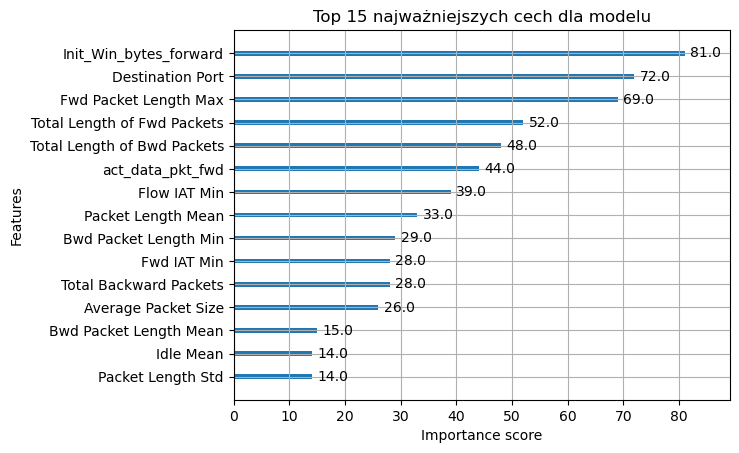

In [78]:
# Wizualizacja ważności cech
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15, importance_type='weight')
plt.title("Top 15 najważniejszych cech dla modelu")
plt.show()